In [0]:
df_results = spark.read.csv("/Volumes/gr5069/raw/f1_data/results.csv", header=True, inferSchema=True).toPandas()
df_races   = spark.read.csv("/Volumes/gr5069/raw/f1_data/races.csv",   header=True, inferSchema=True).toPandas()
df_drivers = spark.read.csv("/Volumes/gr5069/raw/f1_data/drivers.csv", header=True, inferSchema=True).toPandas()

display(df_results.head())

resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [0]:
# Cell 3 - Feature Engineering
df = df_results.merge(df_races[['raceId','year','round']], on='raceId', how='left')
df = df.merge(df_drivers[['driverId','dob']], on='driverId', how='left')

features = ['grid','year','round','driverId','constructorId','laps','milliseconds']
target = 'positionOrder'

df_model = df[features + [target]].copy()
df_model = df_model.replace('\\N', np.nan)
df_model = df_model.dropna()
df_model = df_model.astype(float)

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 6144 | Test size: 1536


In [0]:
# Create Two Prediction Tables in default database
DB = "default"

spark.sql(f"""
    CREATE TABLE IF NOT EXISTS {DB}.hw5_rf_predictions (
        resultId LONG,
        actual_position DOUBLE,
        predicted_position DOUBLE,
        model_name STRING
    )
""")

spark.sql(f"""
    CREATE TABLE IF NOT EXISTS {DB}.hw5_gbr_predictions (
        resultId LONG,
        actual_position DOUBLE,
        predicted_position DOUBLE,
        model_name STRING
    )
""")

print("Tables created successfully.")

Tables created successfully.


2026/04/28 20:28:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/918966541732606/models/m-0538828aebe2451e866d84deed92b8e3?o=7474645003041195
2026/04/28 20:28:52 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


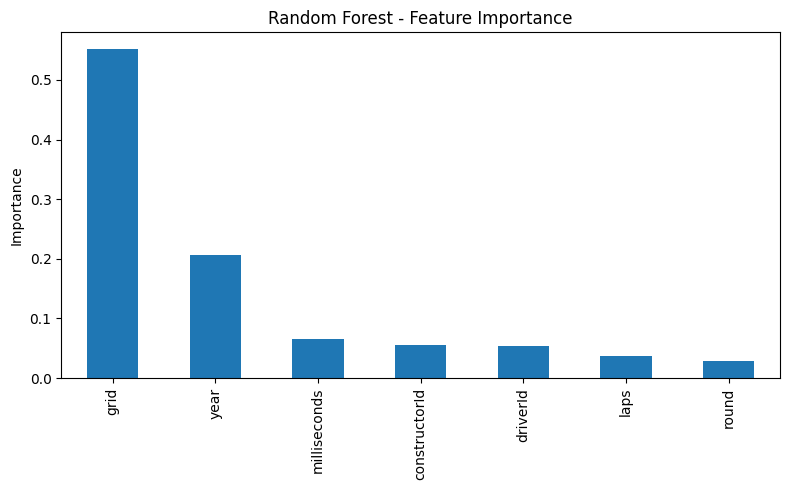

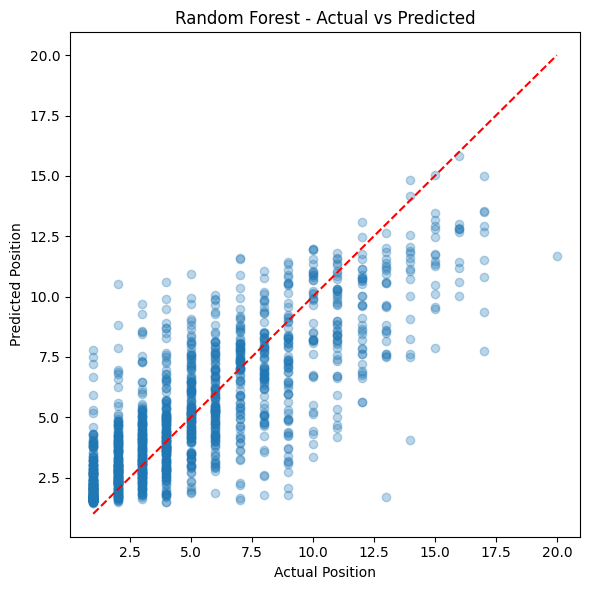

Random Forest => MAE: 1.594 | RMSE: 2.172 | R2: 0.651


In [0]:
# Model 1 Random Forest with MLflow
DB = "default"

with mlflow.start_run(run_name="RandomForest_HW5"):

    # Hyperparameters
    n_estimators     = 100
    max_depth        = 10
    min_samples_split = 5

    mlflow.log_param("model_type",         "RandomForestRegressor")
    mlflow.log_param("n_estimators",       n_estimators)
    mlflow.log_param("max_depth",          max_depth)
    mlflow.log_param("min_samples_split",  min_samples_split)

    # Train
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # Log 4 metrics
    mae  = mean_absolute_error(y_test, y_pred_rf)
    mse  = mean_squared_error(y_test, y_pred_rf)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred_rf)

    mlflow.log_metric("MAE",  mae)
    mlflow.log_metric("MSE",  mse)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2",   r2)

    # Log model
    mlflow.sklearn.log_model(rf, "random_forest_model")

    # Artifact 1: Feature Importance
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    feat_imp.plot(kind='bar', ax=ax)
    ax.set_title("Random Forest - Feature Importance")
    ax.set_ylabel("Importance")
    plt.tight_layout()
    fig.savefig("/tmp/rf_feature_importance.png")
    mlflow.log_artifact("/tmp/rf_feature_importance.png")
    plt.show()

    # Artifact 2: Actual vs Predicted
    fig2, ax2 = plt.subplots(figsize=(6, 6))
    ax2.scatter(y_test, y_pred_rf, alpha=0.3)
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax2.set_xlabel("Actual Position")
    ax2.set_ylabel("Predicted Position")
    ax2.set_title("Random Forest - Actual vs Predicted")
    plt.tight_layout()
    fig2.savefig("/tmp/rf_actual_vs_predicted.png")
    mlflow.log_artifact("/tmp/rf_actual_vs_predicted.png")
    plt.show()

    print(f"Random Forest => MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

In [0]:
#Store RF Predictions into Table
test_indices = X_test.index.tolist()

rf_pred_df = pd.DataFrame({
    'resultId':           test_indices,
    'actual_position':    y_test.values,
    'predicted_position': y_pred_rf,
    'model_name':         'RandomForestRegressor'
})

rf_pred_spark = spark.createDataFrame(rf_pred_df)
rf_pred_spark.write.mode("overwrite").saveAsTable(f"{DB}.hw5_rf_predictions")
display(spark.table(f"{DB}.hw5_rf_predictions").limit(5))

resultId,actual_position,predicted_position,model_name
23717,1.0,2.824572499957625,RandomForestRegressor
20520,9.0,8.957208553133173,RandomForestRegressor
4645,6.0,4.246241703886449,RandomForestRegressor
21281,5.0,8.023667721078972,RandomForestRegressor
15595,1.0,1.8654611899557074,RandomForestRegressor


2026/04/28 20:29:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/918966541732606/models/m-7281e1f1ee9b46e6acccc6d313329aca?o=7474645003041195
2026/04/28 20:29:32 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


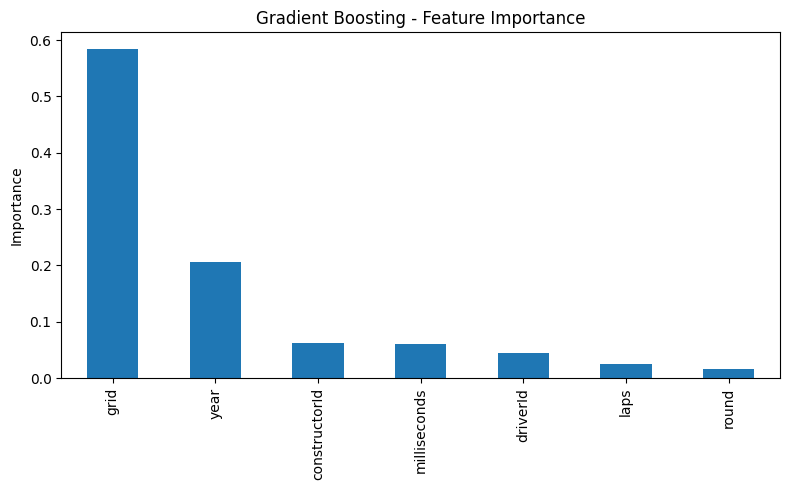

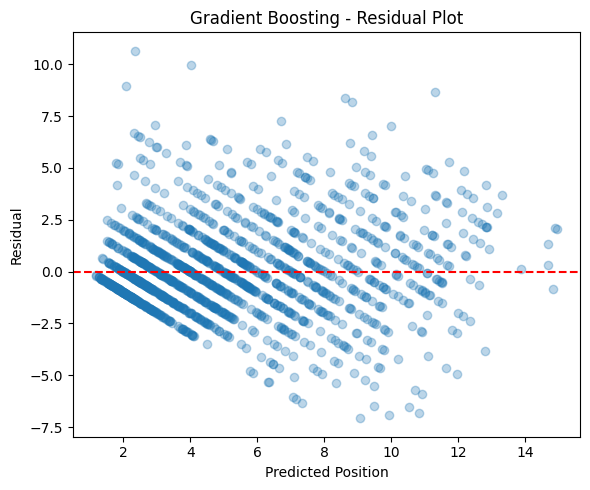

Gradient Boosting => MAE: 1.559 | RMSE: 2.132 | R2: 0.664


In [0]:
# Model 2 Gradient Boosting with MLflow
with mlflow.start_run(run_name="GradientBoosting_HW5"):

    # Hyperparameters
    n_estimators_gbr = 150
    learning_rate    = 0.05
    max_depth_gbr    = 5

    mlflow.log_param("model_type",     "GradientBoostingRegressor")
    mlflow.log_param("n_estimators",   n_estimators_gbr)
    mlflow.log_param("learning_rate",  learning_rate)
    mlflow.log_param("max_depth",      max_depth_gbr)

    # Train
    gbr = GradientBoostingRegressor(
        n_estimators=n_estimators_gbr,
        learning_rate=learning_rate,
        max_depth=max_depth_gbr,
        random_state=42
    )
    gbr.fit(X_train, y_train)
    y_pred_gbr = gbr.predict(X_test)

    # Log 4 metrics
    mae_g  = mean_absolute_error(y_test, y_pred_gbr)
    mse_g  = mean_squared_error(y_test, y_pred_gbr)
    rmse_g = np.sqrt(mse_g)
    r2_g   = r2_score(y_test, y_pred_gbr)

    mlflow.log_metric("MAE",  mae_g)
    mlflow.log_metric("MSE",  mse_g)
    mlflow.log_metric("RMSE", rmse_g)
    mlflow.log_metric("R2",   r2_g)

    # Log model
    mlflow.sklearn.log_model(gbr, "gradient_boosting_model")

    # Artifact 1: Feature Importance
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    feat_imp_gbr = pd.Series(gbr.feature_importances_, index=features).sort_values(ascending=False)
    feat_imp_gbr.plot(kind='bar', ax=ax3)
    ax3.set_title("Gradient Boosting - Feature Importance")
    ax3.set_ylabel("Importance")
    plt.tight_layout()
    fig3.savefig("/tmp/gbr_feature_importance.png")
    mlflow.log_artifact("/tmp/gbr_feature_importance.png")
    plt.show()

    # Artifact 2: Residual Plot
    residuals = y_test.values - y_pred_gbr
    fig4, ax4 = plt.subplots(figsize=(6, 5))
    ax4.scatter(y_pred_gbr, residuals, alpha=0.3)
    ax4.axhline(0, color='red', linestyle='--')
    ax4.set_xlabel("Predicted Position")
    ax4.set_ylabel("Residual")
    ax4.set_title("Gradient Boosting - Residual Plot")
    plt.tight_layout()
    fig4.savefig("/tmp/gbr_residuals.png")
    mlflow.log_artifact("/tmp/gbr_residuals.png")
    plt.show()

    print(f"Gradient Boosting => MAE: {mae_g:.3f} | RMSE: {rmse_g:.3f} | R2: {r2_g:.3f}")

In [0]:
# Store GBR Predictions into Table
gbr_pred_df = pd.DataFrame({
    'resultId':           test_indices,
    'actual_position':    y_test.values,
    'predicted_position': y_pred_gbr,
    'model_name':         'GradientBoostingRegressor'
})

gbr_pred_spark = spark.createDataFrame(gbr_pred_df)
gbr_pred_spark.write.mode("overwrite").saveAsTable(f"{DB}.hw5_gbr_predictions")
display(spark.table(f"{DB}.hw5_gbr_predictions").limit(5))

resultId,actual_position,predicted_position,model_name
23717,1.0,2.42943338433822,GradientBoostingRegressor
20520,9.0,9.481438267954317,GradientBoostingRegressor
4645,6.0,3.941238951332706,GradientBoostingRegressor
21281,5.0,6.905607820676157,GradientBoostingRegressor
15595,1.0,1.8574604395364418,GradientBoostingRegressor


In [0]:
# Verify Both Tables
print("=== RF Predictions Table ===")
display(spark.table(f"{DB}.hw5_rf_predictions"))

print("=== GBR Predictions Table ===")
display(spark.table(f"{DB}.hw5_gbr_predictions"))

=== RF Predictions Table ===


resultId,actual_position,predicted_position,model_name
23717,1.0,2.824572499957625,RandomForestRegressor
20520,9.0,8.957208553133173,RandomForestRegressor
4645,6.0,4.246241703886449,RandomForestRegressor
21281,5.0,8.023667721078972,RandomForestRegressor
15595,1.0,1.8654611899557074,RandomForestRegressor
3372,4.0,3.455634912811915,RandomForestRegressor
21119,11.0,8.850183516220724,RandomForestRegressor
18551,10.0,11.540301176792555,RandomForestRegressor
89,2.0,3.3414963673265614,RandomForestRegressor
4074,3.0,5.383204650630469,RandomForestRegressor


=== GBR Predictions Table ===


resultId,actual_position,predicted_position,model_name
23717,1.0,2.42943338433822,GradientBoostingRegressor
20520,9.0,9.481438267954317,GradientBoostingRegressor
4645,6.0,3.941238951332706,GradientBoostingRegressor
21281,5.0,6.905607820676157,GradientBoostingRegressor
15595,1.0,1.8574604395364418,GradientBoostingRegressor
3372,4.0,4.555339163824727,GradientBoostingRegressor
21119,11.0,9.586180611803734,GradientBoostingRegressor
18551,10.0,11.14767832603664,GradientBoostingRegressor
89,2.0,3.3185050504963054,GradientBoostingRegressor
4074,3.0,4.8425757701852765,GradientBoostingRegressor
